In [24]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_API_KEY")
os.environ["OPENAI_ENDPOINT"] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ["OPENAI_API_VERSION"] = "2024-12-01-preview"
os.environ["OPENAI_DEPLOYMENT_NAME"] = "gpt-4o-mini"
os.environ["OPENAI_MODEL"] = "gpt-4o-mini"

open_api_key = os.getenv("AZURE_OPENAI_API_KEY")
if os.getenv("AZURE_OPENAI_API_KEY"):
    print(f"Azure Open API Key loaded: {open_api_key[:10]}...{open_api_key[-4:]}")
    print(f"Model: {os.getenv('OPENAI_MODEL')}")
    os.environ["OPENAI_API_KEY"] = open_api_key
else:
    print("Azure API Key not found in environment variables")
    print("Available environment variables with 'Azure':", [k for k in os.environ.keys() if 'Azure' in k.upper()])

groq_api_key = os.getenv("GROQ_API_KEY")
if os.getenv("GROQ_API_KEY"):
    print(f"GROQ API Key loaded: {groq_api_key[:10]}...{groq_api_key[-4:]}")
    os.environ["GROQ_API_KEY"] = groq_api_key
else:
    print("GROQ API Key not found in environment variables")
    print("Available environment variables with 'GROQ':", [k for k in os.environ.keys() if 'GROQ' in k.upper()])

tavily_api_key = os.getenv("TAVILY_API_KEY")
if tavily_api_key:
    print(f"Tavily API Key loaded: {tavily_api_key[:10]}...{tavily_api_key[-4:]}")
else:
    print("Tavily API Key not found in environment variables")
    print("Available environment variables with 'TAVILY':", [k for k in os.environ.keys() if 'TAVILY' in k.upper()])

Azure Open API Key loaded: 1Sttw3VbMy...EzVq
Model: gpt-4o-mini
GROQ API Key loaded: gsk_kJ3nEw...OOCG
Tavily API Key loaded: tvly-dev-h...xnHL


In [25]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_core.tools import tool


In [26]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv)

api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)


In [27]:
arxiv.invoke("Attention is all you need ")


"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with low latencies remains challenging due to the quadratic input length\ncomplexity of the attention layers. In this work, we investigate the effect of\ndropping MLP and attention layers at inference time o"

In [28]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki)

api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/home/zama/Desktop/code/Roadmap-To-AI-ML/langgraph/venv/lib/python3.12/site-packages/wikipedia/__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=500)


In [29]:
wiki.invoke("what is machine learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [30]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(
    api_key=os.getenv("TAVILY_API_KEY"),
    top_k=2,
    max_results=2,
    max_content_length=500
)
tavily

TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))

In [31]:
tavily.invoke("What is the latest in AI research?")

{'query': 'What is the latest in AI research?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': "What's next for AI in 2025 - MIT Technology Review",
   'url': 'https://www.technologyreview.com/2025/01/08/1109188/whats-next-for-ai-in-2025/',
   'content': 'AI model makers are also keen to pitch their generative products as research tools for scientists. OpenAI let scientists test its latest o1 model and see how it might support them in research.',
   'score': 0.5832277,
   'raw_content': None},
  {'title': 'Artificial Intelligence News -- ScienceDaily',
   'url': 'https://www.sciencedaily.com/news/computers_math/artificial_intelligence/',
   'content': 'Artificial Intelligence News. Everything on AI including futuristic robots with artificial intelligence, computer models of human intelligence and more.',
   'score': 0.41805586,
   'raw_content': None}],
 'response_time': 1.67}

In [32]:
tools = [arxiv, wiki, tavily]

In [33]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="gemma2-9b-it",
    api_key=os.getenv("GROQ_API_KEY")
)
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7d3d39050fb0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7d3d386844d0>, model_name='gemma2-9b-it', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [34]:
llm_with_tools = llm.bind_tools(tools)

In [35]:
from langchain.schema import HumanMessage, SystemMessage, AIMessage

# tavily
response = llm_with_tools.invoke([
    HumanMessage(
        content="What is the recent AI news"
    )
]).tool_calls
response


[{'name': 'tavily_search',
  'args': {'query': 'recent AI news', 'topic': 'news'},
  'id': 'cke4g05qb',
  'type': 'tool_call'}]

In [36]:
response = llm_with_tools.invoke([
    HumanMessage(
        content="What gold price in india"
    )
]).tool_calls
response

[{'name': 'wikipedia',
  'args': {'query': 'Gold price in India'},
  'id': 'dj7bdq55n',
  'type': 'tool_call'}]

In [37]:

response = llm_with_tools.invoke([
    HumanMessage(
        content="Share details on Attention is all you need paper"
    )
]).tool_calls
response

[{'name': 'arxiv',
  'args': {'query': 'Attention is All You Need'},
  'id': 'qp61b9ph4',
  'type': 'tool_call'}]

In [38]:
# State schema
from typing import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


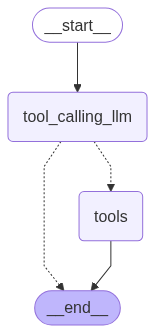

In [39]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
# node
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

#Build graph
builder = StateGraph(State)

#nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

#edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", 
    tools_condition,
)
builder.add_edge("tools", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# arxiv
messages = graph.invoke(
    {"messages": HumanMessage(content="1706.03762")}
)

for m in messages['messages']:
    m.pretty_print()



================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (4tzhmdegd)
 Call ID: 4tzhmdegd
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks in an encoder-decoder configuration. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer, base


In [ ]:
# tavily
messages = graph.invoke(
    {"messages": HumanMessage(content="Share top 10 recent AI news from this month")}
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Share top 10 recent AI news from this month
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ymegzkkzr)
 Call ID: ymegzkkzr
  Args:
    query: AI news
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnet.com/tech/services-and-software/features/ai-essentials-29-ways-to-make-gen-ai-work-for-you-according-to-our-experts/", "title": "AI Essentials: 29 Ways to Make Gen AI Work for You, According to Our Experts - CNET", "score": 0.5957048, "published_date": "Sat, 07 Jun 2025 13:35:00 GMT", "content": "Inside the Rise of 7,000 Starlink Satellites – and Their Inevitable Downfall\n\nBig TVs Are the Next Frontier, but It's a Co

In [ ]:
# wiki
messages = graph.invoke(
    {"messages": HumanMessage(content="what is machine learning")}
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (dnf1y4z57)
 Call ID: dnf1y4z57
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
